# 🌊 Flood Prediction System using Comparative Machine Learning Models
### Complete Unified Master Notebook

This comprehensive notebook contains the full pipeline for **Comparative Prediction Models**, incorporating:
1. **Dynamic Dataset Loading via Kagglehub** (`varshithnagubandi/flood-prediction`)
2. **Exploratory Data Analysis (EDA)** (KDE distributions & categorical counts)
3. **Logistic Regression Pipeline** (Training & Prediction)
4. **Random Forest Pipeline** (Training, Feature Importance & Prediction)
5. **Support Vector Machine (SVM) Pipeline** (Training & Prediction)
6. **XGBoost Pipeline** (Training, Feature Importance & Prediction)
7. **Comparative Model Performance Summary**

## 0. Install Dependencies & Setup Environment

In [1]:
# Install required dependencies for Google Colab / local environment
!pip install -q kagglehub pandas numpy scikit-learn xgboost matplotlib seaborn joblib

import os, sys, re, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

%matplotlib inline
sns.set_style('whitegrid')


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\varsh\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip
C:\Users\varsh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Dynamic Dataset Loading (`load_flood_data` / `kagglehub`)

In [2]:
sys.path.insert(0, '../scripts')
try:
    from data_loader import load_flood_data
    df = load_flood_data(dataset_handle='varshithnagubandi/flood-prediction', file_name='flood.csv', local_path='../data/flood.csv')
except Exception:
    print('Downloading dataset via kagglehub...')
    path = kagglehub.dataset_download('varshithnagubandi/flood-prediction')
    df = pd.read_csv(os.path.join(path, 'flood.csv'))

# Clean column names
df.columns = [re.sub(r'[^a-zA-Z0-9]+', '_', col.lower()).strip('_') for col in df.columns]
print('Dataset Loaded Successfully! Shape:', df.shape)
df.head()

Fetching dataset 'varshithnagubandi/flood-prediction' via kagglehub...
Successfully loaded 'flood.csv' from Kaggle cache.
Dataset Loaded Successfully! Shape: (10000, 14)


,latitude,longitude,rainfall,temperature_c,humidity,river_discharge_m_s,water_level_m,elevation_m,land_cover,soil_type,population_density,infrastructure,floods,flood_occurred
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,Water Body,Clay,7276.742184,1,0,1
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,0,1,0
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1,1,0
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,1,0,0


## 2. Exploratory Data Analysis (EDA)

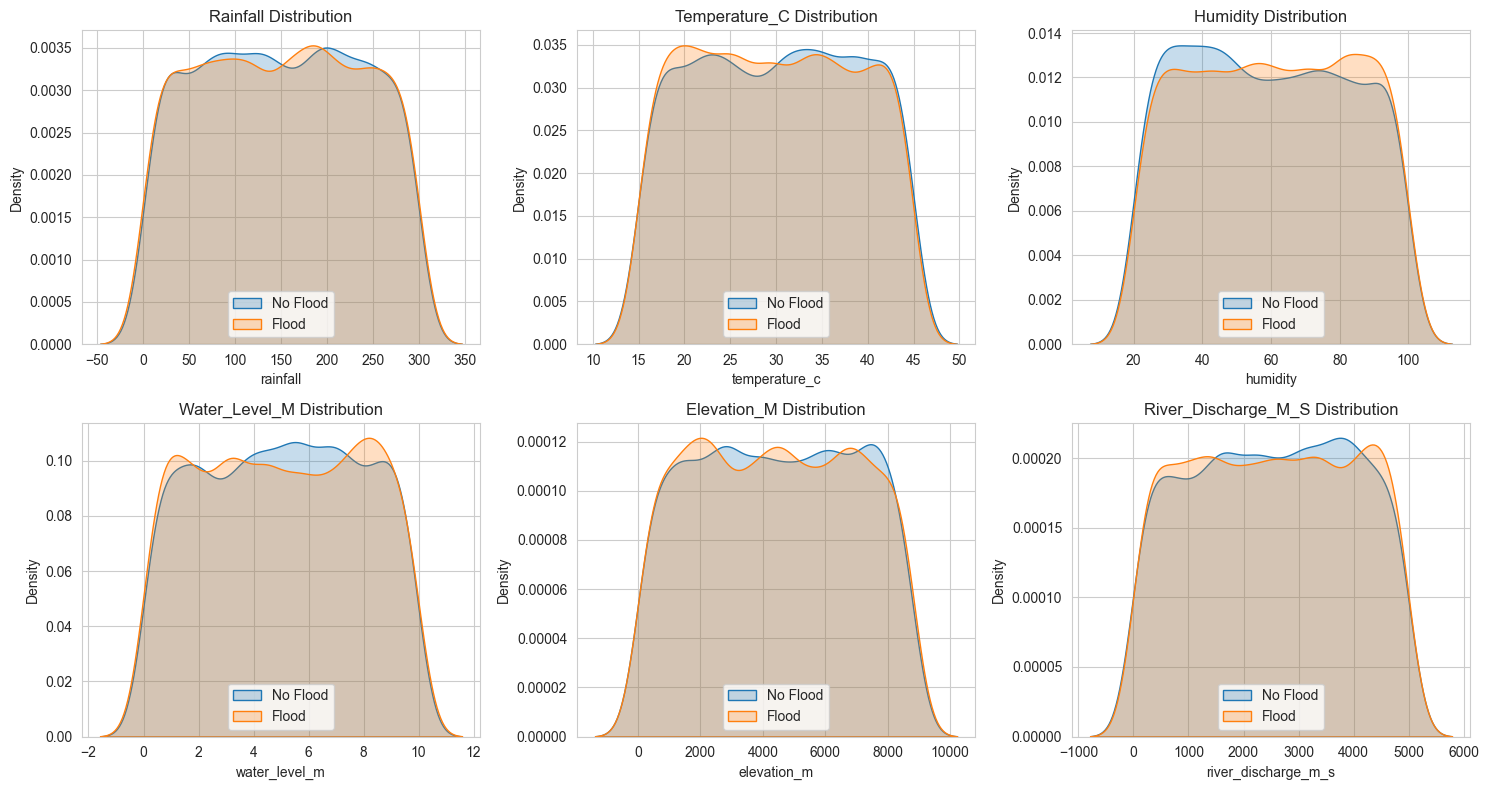

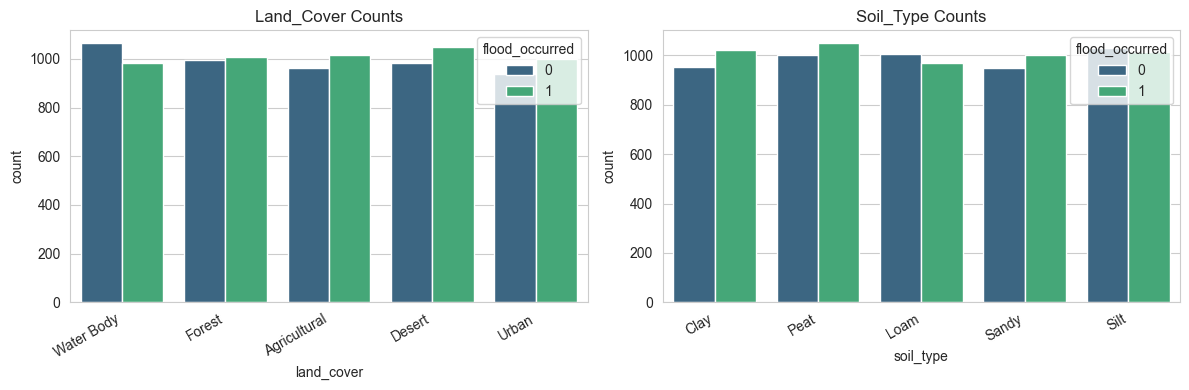

In [3]:
# Analyze Numerical Features
numerical_features = ['rainfall', 'temperature_c', 'humidity', 'water_level_m', 'elevation_m', 'river_discharge_m_s']
plt.figure(figsize=(15, 8))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(df[df['flood_occurred'] == 0][feature], label='No Flood', fill=True)
    sns.kdeplot(df[df['flood_occurred'] == 1][feature], label='Flood', fill=True)
    plt.title(f'{feature.title()} Distribution')
    plt.legend()
plt.tight_layout()
plt.show()

# Analyze Categorical Features
categorical_features = ['land_cover', 'soil_type']
plt.figure(figsize=(12, 4))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(1, 2, i)
    sns.countplot(data=df, x=feature, hue='flood_occurred', palette='viridis')
    plt.title(f'{feature.title()} Counts')
    plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Feature Scaling

In [6]:
feature_names = ['rainfall', 'temperature_c', 'humidity', 'water_level_m', 'elevation_m']
target_name = 'flood_occurred'

X = df[feature_names]
y = df[target_name]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ensure output directories exist
os.makedirs('../models', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

## 4. Logistic Regression Model

Logistic Regression Model Accuracy: 51.75%

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.43      0.46       966
           1       0.53      0.60      0.56      1034

    accuracy                           0.52      2000
   macro avg       0.52      0.51      0.51      2000
weighted avg       0.52      0.52      0.51      2000



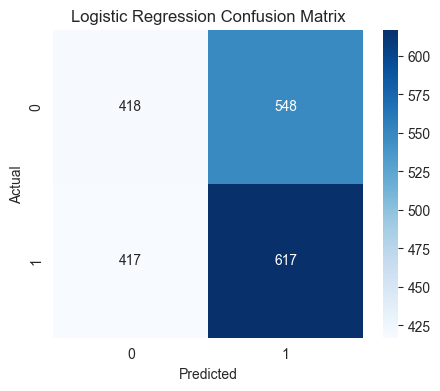

Saved Logistic Regression model and scaler to models/


In [7]:
# Train Logistic Regression Model
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression Model Accuracy: {lr_acc * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

# Plot Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# Save Model & Scaler
joblib.dump(lr_model, '../models/logistic_regression_model.joblib')
joblib.dump(scaler, '../models/logistic_regression_scaler.joblib')
print('Saved Logistic Regression model and scaler to models/')

## 5. Random Forest Model

Random Forest Model Accuracy: 51.55%

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.52      0.51       966
           1       0.53      0.51      0.52      1034

    accuracy                           0.52      2000
   macro avg       0.52      0.52      0.52      2000
weighted avg       0.52      0.52      0.52      2000



C:\Users\varsh\AppData\Local\Temp\ipykernel_24748\953129095.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importance, palette='crest')


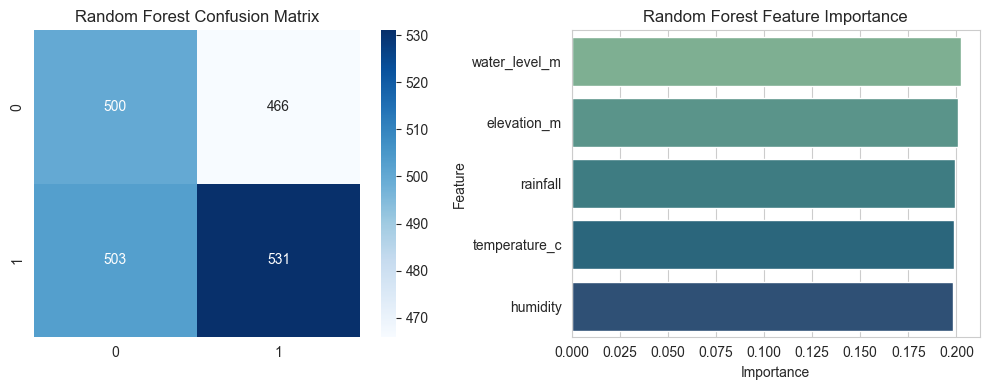

Saved Random Forest model and scaler to models/


In [8]:
# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

rf_acc = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Model Accuracy: {rf_acc * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

# Plot Confusion Matrix & Feature Importance
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')

plt.subplot(1, 2, 2)
rf_importance = pd.DataFrame({'Feature': feature_names, 'Importance': rf_model.feature_importances_}).sort_values(by='Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=rf_importance, palette='crest')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

# Save Model & Scaler
joblib.dump(rf_model, '../models/random_forest_model.joblib')
joblib.dump(scaler, '../models/random_forest_scaler.joblib')
print('Saved Random Forest model and scaler to models/')

## 6. Support Vector Machine (SVM) Model

SVM Model Accuracy: 51.55%

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.51      0.50       966
           1       0.53      0.52      0.53      1034

    accuracy                           0.52      2000
   macro avg       0.52      0.52      0.52      2000
weighted avg       0.52      0.52      0.52      2000



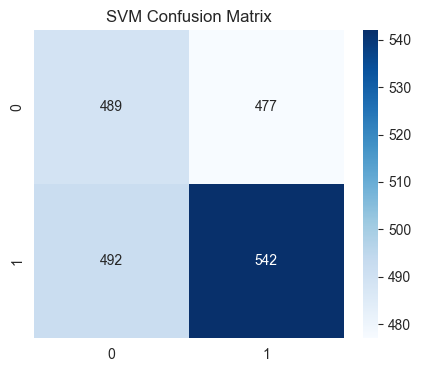

Saved SVM model and scaler to models/


In [9]:
# Train SVM Model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, y_pred_svm)
print(f'SVM Model Accuracy: {svm_acc * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm))

# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.show()

# Save Model & Scaler
joblib.dump(svm_model, '../models/svm_model.joblib')
joblib.dump(scaler, '../models/svm_scaler.joblib')
print('Saved SVM model and scaler to models/')

## 7. XGBoost Model

XGBoost Model Accuracy: 53.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.52      0.52       966
           1       0.55      0.55      0.55      1034

    accuracy                           0.54      2000
   macro avg       0.53      0.53      0.53      2000
weighted avg       0.54      0.54      0.54      2000



C:\Users\varsh\AppData\Local\Temp\ipykernel_24748\532071169.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_importance, palette='viridis')


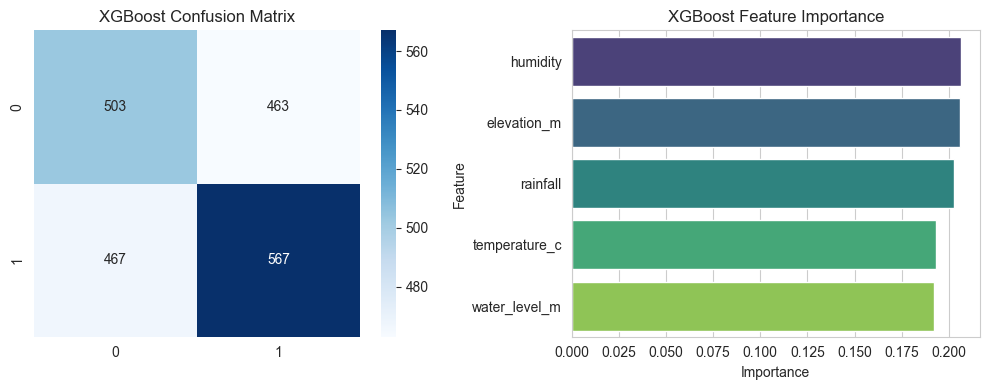

Saved XGBoost model and scaler to models/


In [10]:
# Train XGBoost Model
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
print(f'XGBoost Model Accuracy: {xgb_acc * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

# Plot Confusion Matrix & Feature Importance
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')

plt.subplot(1, 2, 2)
xgb_importance = pd.DataFrame({'Feature': feature_names, 'Importance': xgb_model.feature_importances_}).sort_values(by='Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=xgb_importance, palette='viridis')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

# Save Model & Scaler
joblib.dump(xgb_model, '../models/xgboost_model.joblib')
joblib.dump(scaler, '../models/xgboost_scaler.joblib')
print('Saved XGBoost model and scaler to models/')

## 8. Comparative Performance Comparison & Summary

,Model,Accuracy (%)
3,XGBoost,53.50
0,Logistic Regression,51.75
1,Random Forest,51.55
2,SVM,51.55


C:\Users\varsh\AppData\Local\Temp\ipykernel_24748\2673305055.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='Model', y='Accuracy (%)', palette='mako')


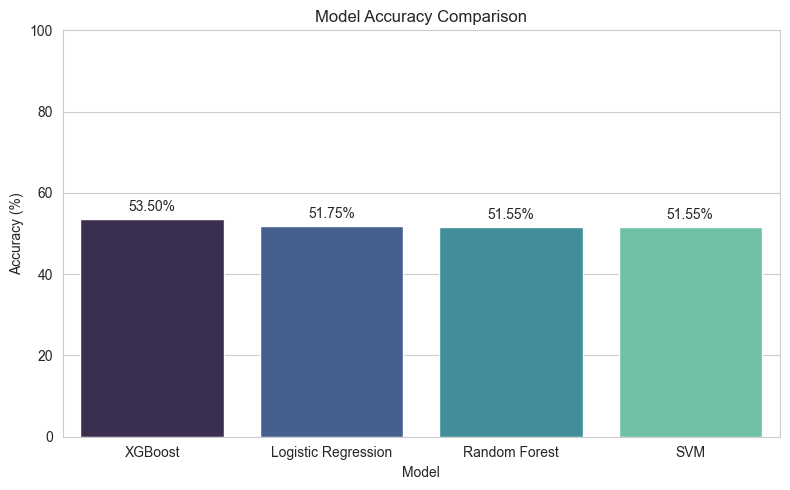

In [11]:
accuracy_summary = {
    'Logistic Regression': lr_acc * 100,
    'Random Forest': rf_acc * 100,
    'SVM': svm_acc * 100,
    'XGBoost': xgb_acc * 100
}

summary_df = pd.DataFrame(list(accuracy_summary.items()), columns=['Model', 'Accuracy (%)'])
summary_df = summary_df.sort_values(by='Accuracy (%)', ascending=False)
display(summary_df)

# Plot Comparison Bar Chart
plt.figure(figsize=(8, 5))
sns.barplot(data=summary_df, x='Model', y='Accuracy (%)', palette='mako')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 100)
for i, row in enumerate(summary_df.itertuples()):
    plt.text(i, row._2 + 2, f'{row._2:.2f}%', ha='center')
plt.tight_layout()
plt.show()

## 9. Interactive Prediction Demo

In [13]:
# Sample input features: [rainfall, temperature_c, humidity, water_level_m, elevation_m]
sample_input = pd.DataFrame([[218.9, 34.1, 43.9, 7.4, 377.4]], columns=feature_names)
sample_scaled = scaler.transform(sample_input)

pred_lr = lr_model.predict(sample_scaled)[0]
pred_rf = rf_model.predict(sample_scaled)[0]
pred_svm = svm_model.predict(sample_scaled)[0]
pred_xgb = xgb_model.predict(sample_scaled)[0]

print('=== SAMPLE INFERENCE PREDICTIONS ===')
print('Input Features:', sample_input.to_dict(orient='records')[0])
print(f'Logistic Regression Prediction: {pred_lr} (Flood)' if pred_lr == 1 else f'Logistic Regression Prediction: {pred_lr} (No Flood)')
print(f'Random Forest Prediction       : {pred_rf} (Flood)' if pred_rf == 1 else f'Random Forest Prediction       : {pred_rf} (No Flood)')
print(f'SVM Prediction                 : {pred_svm} (Flood)' if pred_svm == 1 else f'SVM Prediction                 : {pred_svm} (No Flood)')
print(f'XGBoost Prediction             : {pred_xgb} (Flood)' if pred_xgb == 1 else f'XGBoost Prediction             : {pred_xgb} (No Flood)')

=== SAMPLE INFERENCE PREDICTIONS ===
Input Features: {'rainfall': 218.9, 'temperature_c': 34.1, 'humidity': 43.9, 'water_level_m': 7.4, 'elevation_m': 377.4}
Logistic Regression Prediction: 0 (No Flood)
Random Forest Prediction       : 1 (Flood)
SVM Prediction                 : 0 (No Flood)
XGBoost Prediction             : 1 (Flood)
